# Chapter 5: Confidence intervals as the dual of tests

Each cell below mirrors a loop in `chapter.log`. Edit the input variables and re-run to feel how the intervals respond.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from statsmodels.stats.proportion import proportion_confint
from expkit.inference.binomial import wilson_ci, clopper_pearson_ci
from expkit.inference.bootstrap import bootstrap_ci
from expkit.plot.style import apply_style, PALETTE
apply_style()

## Loop A: same data, five intervals

Pick a `(k, n)` and watch the five 95% intervals line up. They should agree at large N and diverge at small N.

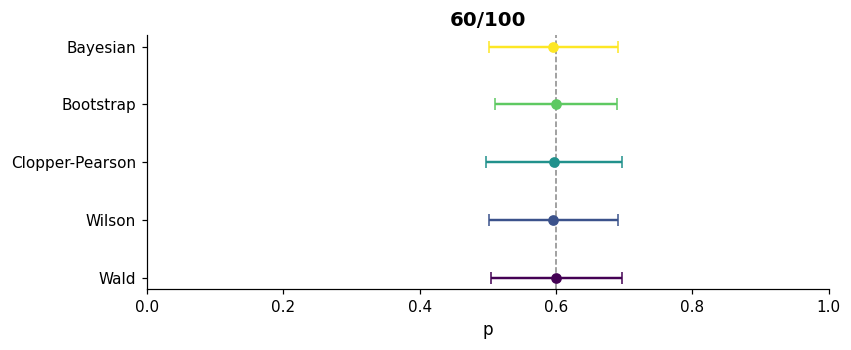

Wald               [0.504, 0.696]  width = 0.192
Wilson             [0.502, 0.691]  width = 0.189
Clopper-Pearson    [0.497, 0.697]  width = 0.199
Bootstrap          [0.510, 0.690]  width = 0.180
Bayesian           [0.502, 0.691]  width = 0.189


In [2]:
def show_intervals(k, n):
    seq = np.concatenate([np.ones(k), np.zeros(n - k)])
    wald = proportion_confint(k, n, method='normal')
    wilson = wilson_ci(k, n)
    cp = clopper_pearson_ci(k, n)
    bs_lo, bs_hi, _ = bootstrap_ci(seq, n_boot=2000, seed=0)
    a, b = 1 + k, 1 + (n - k)
    bayes = (float(beta_dist.ppf(0.025, a, b)), float(beta_dist.ppf(0.975, a, b)))
    methods = [('Wald', wald), ('Wilson', wilson), ('Clopper-Pearson', cp), ('Bootstrap', (bs_lo, bs_hi)), ('Bayesian', bayes)]
    fig, ax = plt.subplots(figsize=(8, 3.0))
    cmap = plt.get_cmap('viridis')
    for j, (name, (lo, hi)) in enumerate(methods):
        ax.errorbar((lo+hi)/2, j, xerr=[[(lo+hi)/2 - lo], [hi - (lo+hi)/2]], fmt='o', capsize=4, color=cmap(j/4))
    ax.set_yticks(range(len(methods))); ax.set_yticklabels([m[0] for m in methods])
    ax.axvline(k/n, color=PALETTE['muted'], linestyle='--', linewidth=1)
    ax.set_xlim(0, 1); ax.set_xlabel('p'); ax.set_title(f'{k}/{n}')
    plt.show()
    for name, (lo, hi) in methods:
        print(f'{name:<18} [{lo:.3f}, {hi:.3f}]  width = {hi-lo:.3f}')

show_intervals(60, 100)

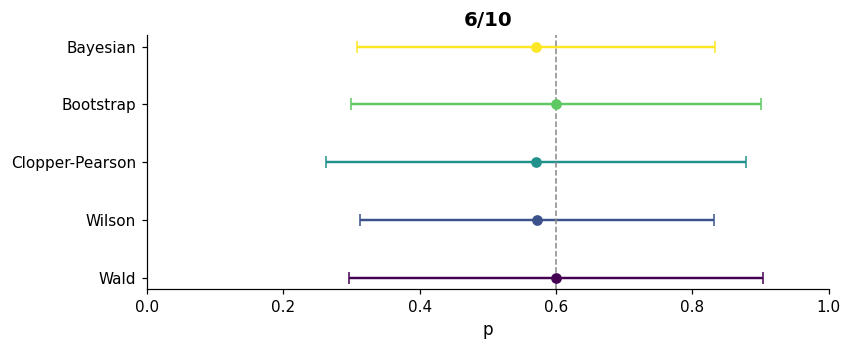

Wald               [0.296, 0.904]  width = 0.607
Wilson             [0.313, 0.832]  width = 0.519
Clopper-Pearson    [0.262, 0.878]  width = 0.616
Bootstrap          [0.300, 0.900]  width = 0.600
Bayesian           [0.308, 0.833]  width = 0.525


In [3]:
# Try a different observation; small N exaggerates the differences.
show_intervals(6, 10)

## Loop B: Wald breaks at boundaries

In [4]:
for k, n in [(0, 10), (10, 10), (0, 100), (100, 100)]:
    print(f'{k}/{n}:  Wald = {proportion_confint(k, n, method="normal")}  Wilson = {wilson_ci(k, n)}  Clopper-Pearson = {clopper_pearson_ci(k, n)}')

0/10:  Wald = (0.0, 0.0)  Wilson = (0.0, 0.27753279986288926)  Clopper-Pearson = (0.0, 0.30849710781876083)
10/10:  Wald = (1.0, 1.0)  Wilson = (0.7224672001371106, 1.0)  Clopper-Pearson = (0.6915028921812392, 1.0)
0/100:  Wald = (0.0, 0.0)  Wilson = (0.0, 0.03699349820698569)  Clopper-Pearson = (0.0, 0.03621669264517642)
100/100:  Wald = (1.0, 1.0)  Wilson = (0.9630065017930143, 1.0)  Clopper-Pearson = (0.9637833073548235, 1.0)


## Loop C: priors that argue

Same data (60 heads in 100 tosses). Three priors. Watch the posteriors diverge.

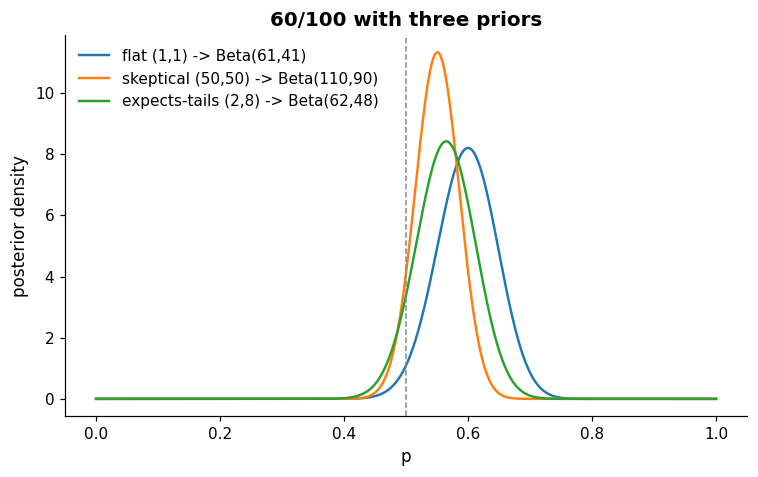

In [5]:
k, n = 60, 100
ps = np.linspace(0, 1, 1000)
fig, ax = plt.subplots()
for name, (a0, b0) in [('flat (1,1)', (1,1)), ('skeptical (50,50)', (50,50)), ('expects-tails (2,8)', (2,8))]:
    a, b = a0 + k, b0 + (n - k)
    ax.plot(ps, beta_dist.pdf(ps, a, b), label=f'{name} -> Beta({a},{b})')
ax.axvline(0.5, color=PALETTE['muted'], linestyle='--', linewidth=1)
ax.set_xlabel('p'); ax.set_ylabel('posterior density'); ax.set_title('60/100 with three priors'); ax.legend()
plt.show()

## Loop D: empirical coverage at N = 20

In [ ]:
n, n_trials = 20, 5000
rng = np.random.default_rng(0)
counts = rng.binomial(n, 0.5, size=n_trials)
covered = {'Wald': 0, 'Wilson': 0, 'Clopper-Pearson': 0, 'Bayesian': 0}
for k in counts:
    for name, m in [('Wald', 'normal'), ('Wilson', 'wilson'), ('Clopper-Pearson', 'beta')]:
        lo, hi = proportion_confint(int(k), n, method=m)
        if lo <= 0.5 <= hi: covered[name] += 1
    a, b = 1 + int(k), 1 + (n - int(k))
    lo = float(beta_dist.ppf(0.025, a, b)); hi = float(beta_dist.ppf(0.975, a, b))
    if lo <= 0.5 <= hi: covered['Bayesian'] += 1
for name, c in covered.items():
    flag = ' (under-covers!)' if c/n_trials < 0.92 else ''
    print(f'{name:<18} empirical coverage = {c/n_trials:.3f}{flag}')

## Try it yourself

Change the cell parameters above (e.g. `(k, n) = (1, 5)`, or push the prior to (200, 200)) and re-run. The pattern: at small N the methods disagree a lot, at large N they converge.